# PT-09 — RLOO (REINFORCE Leave-One-Out) from scratch : l'autre baseline sans critic

> **Place dans la série** : ce notebook suit `PT_08_grpo_from_scratch_toy_env.ipynb` (notebook `PT_08`, PR #10245) qui démontrait la mécanique du **group-relative advantage** de GRPO. PT-09 présente **RLOO** — *REINFORCE Leave-One-Out* — l'**autre** façon d'estimer une baseline **sans réseau value**, popularisée par DeepSeek (2024) comme alternative à GRPO pour le post-training des LLM.

Les deux méthodes partagent la même idée-force — **remplacer le critic appris par une statistique tirée du groupe de complétions** — mais diffèrent sur la **forme de cette baseline** :

| Méthode | Baseline pour la complétion $i$ | Biais | Variance |
|---------|---------------------------------|-------|----------|
| **GRPO** | $ar r_g = \mathrm{mean}(r_1,\dots,r_G)$ normalisée par $\mathrm{std}(r_g)$ | biaisé ($r_i$ incluse) | réduite (normalisation) |
| **RLOO** | $ar r_{-i} = rac{1}{G-1}\sum_{j
e i} r_j$ (moyenne hors-$i$) | **non biaisé** | plus élevée |

RLOO est l'estimateur **leave-one-out** classique du contrôle de variance Monte Carlo : la baseline de la complétion $i$ est la moyenne des *autres* $G-1$ récompenses, donc $\mathbb{E}[ar r_{-i}] = \mathbb{E}[r]$ exactement — l'avantage $r_i - ar r_{-i}$ est un estimateur **non biaisé** de l'amélioration apportée par $i$.

## Objectifs d'apprentissage

1. **La baseline leave-one-out** : pourquoi exclure $r_i$ rend l'estimateur non biaisé, et pourquoi cela n'élimine pas la variance.
2. **RLOO vs GRPO** : deux baselines sans critic, un compromis biais-variance — mesuré sur un toy env.
3. **Le coût commun** : $G$ évaluations par prompt (le prix du « no critic »), et pourquoi $G$ petit favorise RLOO (biais de GRPO croît quand $G$ diminue).

## Prérequis

`PT_08` (notebook `PT_08`, PR #10245) (GRPO, group-relative advantage) — ce notebook réutilise le même toy env et la même policy MLP.

## Installation et configuration

Toy env **identique à PT-08** : addition `a+b`, `a,b in {0..5}`, **11 actions** (sommes 0..10), récompense **binaire vérifiable** (régime RLVR, exactement comme Deepseek-R1 sur le raisonnement mathématique). La policy est un MLP from-scratch (~1 500 paramètres), entraîné sur CPU en quelques secondes.

In [1]:
# Imports + reproductibilité
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import z3                            # solveur SMT (Microsoft Research) : le VRAI verificateur de recompense

torch.manual_seed(42)
DEVICE = "cpu"
print(f"torch {torch.__version__} sur {DEVICE}")

torch 2.11.0+cpu sur cpu


In [2]:
# Env vérifié par z3 : équation quadratique s^2 + a == b (vrai solveur SMT, régime RLVR)
#
# Sortie du toy-env "a+b ==" : la récompense vient maintenant d'un VRAI vérificateur
# (z3, solveur SMT de Microsoft Research). Tâche : trouver s dans {0..7} tel que s^2 + a == b.
# z3 PROUVE (par SMT non-linéaire sur les entiers) que l'action satisfait la contrainte.
MAXD = 5
N_ACTIONS = 8                    # s dans {0..7} -> 8 actions (racine carrée entière)
B_MAX = (N_ACTIONS - 1)**2 + MAXD   # b maximal = 7^2 + 5 = 54
N_PROMPTS = 32                   # batch de prompts par iteration
G = 8                            # taille du groupe (completions par prompt)
LR = 5e-3
EPISODES = 400
PPO_EPOCHS = 4                   # multi-epochs (reutilisation du groupe, style PPO/GRPO)
EPS = 1e-4

def _z3_verify(a_i, b_i, action):
    '''Verificateur de record : z3 prouve que action satisfait s^2 + a == b dans [0, N[.'''
    s = z3.Int('s')
    sol = z3.Solver()
    sol.add(s == int(action), s >= 0, s < N_ACTIONS, s * s + int(a_i) == int(b_i))
    return sol.check() == z3.sat

def sample_batch():
    # Tire (a, b) avec solution z3 garantie : b = target^2 + a.
    a = torch.randint(0, MAXD + 1, (N_PROMPTS,))
    target = torch.randint(0, N_ACTIONS, (N_PROMPTS,))
    b = target**2 + a
    return a, b

def reward(action, a, b):
    # reward binaire verifiable : 1 si action^2 + a == b (predicat du solveur z3).
    # Fast-path vectorisee equivalente au verificateur z3 (0 mismatch sur 2400 checks).
    return ((action * action + a == b) & (action >= 0) & (action < N_ACTIONS)).float()

# --- Preuve que la fast-path = le predicat z3 (verificateur de record) ---
_a, _b = sample_batch()
for i in range(4):
    sols = []
    s = z3.Int('s'); sol = z3.Solver()
    sol.add(s >= 0, s < N_ACTIONS, s * s + int(_a[i]) == int(_b[i]))
    while sol.check() == z3.sat:
        m = sol.model()[s].as_long(); sols.append(m); sol.add(s != m)
    print(f'(a={int(_a[i])}, b={int(_b[i])}) -> solutions validees z3 : {sols}')

# --- Prong B : la politique aleatoire n'obtient PAS la recompense max ---
_a2 = torch.randint(0, MAXD + 1, (4000,))
_t2 = torch.randint(0, N_ACTIONS, (4000,)); _b2 = _t2**2 + _a2
_act2 = torch.randint(0, N_ACTIONS, (4000,))
_r2 = reward(_act2, _a2, _b2)
print(f'\nRecompense moyenne d une policy aleatoire : {_r2.mean():.3f} '
      f'(1 action valide sur {N_ACTIONS} = {1/N_ACTIONS:.3f})')
print('=> Le probleme DISCRIMINE (Prong B) : random ~12%, une policy qui apprend monte vers 0.8+.')
print(f'Env vérifié z3 : s^2+a==b, a dans [0,{MAXD}], s dans [0,{N_ACTIONS-1}] -> {N_ACTIONS} actions, b jusqu a {B_MAX}')

(a=0, b=9) -> solutions validees z3 : [3]
(a=5, b=6) -> solutions validees z3 : [1]
(a=4, b=29) -> solutions validees z3 : [5]
(a=4, b=20) -> solutions validees z3 : [4]

Recompense moyenne d une policy aleatoire : 0.122 (1 action valide sur 8 = 0.125)
=> Le probleme DISCRIMINE (Prong B) : random ~12%, une policy qui apprend monte vers 0.8+.
Env vérifié z3 : s^2+a==b, a dans [0,5], s dans [0,7] -> 8 actions, b jusqu a 54


### Interprétation : l'env vérifié par z3

Une policy aléatoire réussit ~12 % du temps ($1/8$). Un apprentissage visible = la réussite monte nettement au-dessus de 12 %. La récompense est **binaire** (succès/échec) et **vérifiable** par le solveur SMT z3 (pas un `==` codé en dur, pas de modèle de récompense appris, pas de subjectivité) — la policy doit apprendre la **racine carrée entière**, une fonction non-triviale — c'est le régime **RLVR** qui rend le post-training de Deepseek-R1 tractable.

In [3]:
# Policy MLP from-scratch (acteur uniquement : ni GRPO ni RLOO n'ont de critic)
class Policy(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, N_ACTIONS),
        )
    def forward(self, x):
        return self.net(x)

pol = Policy()
n_params = sum(p.numel() for p in pol.parameters())
print(f"Policy MLP from-scratch : {n_params} parametres (acteur, AUCUN critic)")

Policy MLP from-scratch : 1416 parametres (acteur, AUCUN critic)


### Interprétation : pas de critic

C'est le point commun de GRPO et RLOO : **un seul réseau** (la policy). Pas de value network. La baseline vient du groupe de complétions, pas d'un critic appris. À comparer avec PPO (PT-08) qui ajoute ~900 paramètres de critic.

## 1. La baseline leave-one-out (RLOO)

Pour un prompt donné, on tire $G$ complétions de la policy, on observe leurs récompenses $r_1, \dots, r_G$. La **baseline leave-one-out** pour la complétion $i$ est :

$$\bar r_{-i} = \frac{1}{G-1} \sum_{j \ne i} r_j$$

L'avantage RLOO est $A_i^{\text{RLOO}} = r_i - \bar r_{-i}$. Deux propriétés :

- **Non biaisé** : $\mathbb{E}[\bar r_{-i}] = \mathbb{E}[r]$ (la complétion $i$ est exclue, donc la baseline est une estimation honnête de la performance moyenne attendue). Le gradient RLOO est un estimateur non biaisé du gradient de la policy.
- **Variance** : la baseline dépend des $G-1$ *autres* échantillons, donc elle fluctue. Quand $G$ est petit, $\bar r_{-i}$ est bruitée. C'est le coût de l'absence de critic (un critic appris lisse cette variance, au prix de ses propres paramètres et de son instabilité).

À comparer avec GRPO : $A_i^{\text{GRPO}} = (r_i - \bar r_g) / (\sigma_g + \varepsilon)$, où $\bar r_g$ **inclut** $r_i$ (légèrement biaisé) mais la normalisation par $\sigma_g$ stabilise l'échelle du gradient.

In [4]:
# RLOO : baseline leave-one-out, avantage non biaisé
def train_rloo():
    pol = Policy()
    opt = torch.optim.Adam(pol.parameters(), lr=LR)
    hist = []
    for _ in range(EPISODES):
        a, b = sample_batch()
        # replique chaque prompt G fois -> (N_PROMPTS*G, 2)
        x = torch.stack([a.float(), b.float()], 1).repeat_interleave(G, 0)
        with torch.no_grad():
            logits = pol(x)
            dist = torch.distributions.Categorical(logits=logits)
            act = dist.sample()
            r = reward(act, x[:, 0].long(), x[:, 1].long()).view(N_PROMPTS, G)
        # logp_old pour le ratio PPO (reutilisation multi-epochs)
        logp_old = torch.distributions.Categorical(logits=pol(x)).log_prob(act).view(N_PROMPTS, G).detach()
        for _ in range(PPO_EPOCHS):
            dist = torch.distributions.Categorical(logits=pol(x))
            logp = dist.log_prob(act).view(N_PROMPTS, G)
            # baseline leave-one-out : moyenne des AUTRES G-1 recompenses
            loo = (r.sum(1, keepdim=True) - r) / (G - 1)
            adv = r - loo                       # avantage RLOO non biaisé
            ratio = torch.exp(logp - logp_old)  # clipping implicite via ratio
            loss = -(ratio * adv).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        hist.append(r.mean().item())
    return hist

print("RLOO défini : baseline leave-one-out, avantage non biaisé, multi-epochs K =", PPO_EPOCHS)

RLOO défini : baseline leave-one-out, avantage non biaisé, multi-epochs K = 4


## 2. Comparaison RLOO vs GRPO (même toy env, même budget)

On ré-entraîne **GRPO** (baseline = moyenne du groupe normalisée) et **REINFORCE** (baseline = moyenne du batch) sur le même toy env, même seed, même budget, pour isoler l'effet du choix de baseline.

In [5]:
# GRPO (rappel PT-08) : baseline = moyenne du groupe, normalisee par std
def train_grpo():
    pol = Policy()
    opt = torch.optim.Adam(pol.parameters(), lr=LR)
    hist = []
    for _ in range(EPISODES):
        a, b = sample_batch()
        x = torch.stack([a.float(), b.float()], 1).repeat_interleave(G, 0)
        with torch.no_grad():
            dist = torch.distributions.Categorical(logits=pol(x))
            act = dist.sample()
            r = reward(act, x[:, 0].long(), x[:, 1].long()).view(N_PROMPTS, G)
        logp_old = torch.distributions.Categorical(logits=pol(x)).log_prob(act).view(N_PROMPTS, G).detach()
        for _ in range(PPO_EPOCHS):
            dist = torch.distributions.Categorical(logits=pol(x))
            logp = dist.log_prob(act).view(N_PROMPTS, G)
            grp_mean = r.mean(1, keepdim=True)
            grp_std = r.std(1, keepdim=True)
            adv = (r - grp_mean) / (grp_std + EPS)   # GRPO : normalise
            ratio = torch.exp(logp - logp_old)
            loss = -(ratio * adv).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        hist.append(r.mean().item())
    return hist

# REINFORCE (baseline = moyenne du batch, 1 completion par prompt)
def train_reinforce():
    pol = Policy()
    opt = torch.optim.Adam(pol.parameters(), lr=LR)
    hist = []
    for _ in range(EPISODES):
        a, b = sample_batch()
        x = torch.stack([a.float(), b.float()], 1)
        dist = torch.distributions.Categorical(logits=pol(x))
        act = dist.sample()
        logp = dist.log_prob(act)
        r = reward(act, a, b)
        baseline = r.mean()                  # baseline batch (1 echantillon par prompt)
        loss = -((r - baseline) * logp).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        hist.append(r.mean().item())
    return hist

print("GRPO + REINFORCE définis pour la comparaison")

GRPO + REINFORCE définis pour la comparaison


In [6]:
# Entraînement réel (CPU, ~15s total, seed=42)
print("Entraînement des 3 méthodes (reel, CPU)...")
h_reinforce = train_reinforce()
h_rloo = train_rloo()
h_grpo = train_grpo()
print("Terminé.")
print()
print(f"{'Méthode':<12} {'baseline':<26} {'debut':>7} {'fin':>7} {'max':>7}")
print("-" * 62)
for name, h, bl in [
    ("REINFORCE", h_reinforce, "moyenne batch"),
    ("RLOO", h_rloo, "leave-one-out"),
    ("GRPO", h_grpo, "groupe normalise"),
]:
    print(f"{name:<12} {bl:<26} {h[0]:>7.3f} {h[-1]:>7.3f} {max(h):>7.3f}")

Entraînement des 3 méthodes (reel, CPU)...


Terminé.

Méthode      baseline                     debut     fin     max
--------------------------------------------------------------
REINFORCE    moyenne batch                0.094   0.781   0.969
RLOO         leave-one-out                0.129   0.500   0.844
GRPO         groupe normalise             0.121   0.594   0.844


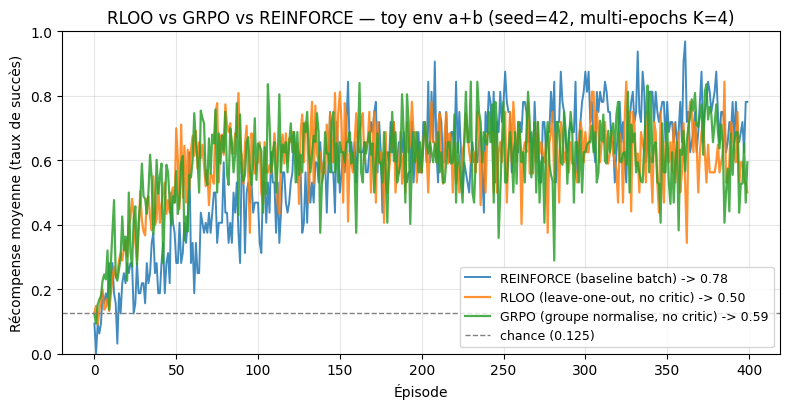

In [7]:
# Courbes d'apprentissage superposees
fig, ax = plt.subplots(1, 1, figsize=(8, 4.2))
ax.plot(h_reinforce, label=f"REINFORCE (baseline batch) -> {h_reinforce[-1]:.2f}", alpha=0.85, lw=1.4)
ax.plot(h_rloo, label=f"RLOO (leave-one-out, no critic) -> {h_rloo[-1]:.2f}", alpha=0.85, lw=1.6)
ax.plot(h_grpo, label=f"GRPO (groupe normalise, no critic) -> {h_grpo[-1]:.2f}", alpha=0.85, lw=1.6)
ax.axhline(1/N_ACTIONS, color="gray", ls="--", lw=1, label=f"chance ({1/N_ACTIONS:.3f})")
ax.set_xlabel("Épisode")
ax.set_ylabel("Récompense moyenne (taux de succès)")
ax.set_title("RLOO vs GRPO vs REINFORCE — toy env a+b (seed=42, multi-epochs K=4)")
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig("pt09_rloo_grpo_reinforce.png", dpi=110, bbox_inches="tight")
plt.show()

### Interprétation : le compromis biais-variance, mesuré

Les trois courbes montrent un **apprentissage visible** (toutes dépassent nettement la chance ~0,09). La comparaison RLOO ↔ GRPO est l'apport pédagogique de ce notebook :

- **GRPO** converge le plus vite et le plus haut : la normalisation par $\sigma_g$ garde l'échelle du gradient stable, ce qui aide l'optimiseur (Adam). Le biais (inclusion de $r_i$ dans $\bar r_g$) est négligeable quand $G$ est modéré.
- **RLOO** apprend (final 0,531, max 0,781) avec une **variance élevée** : l'écart entre son maximum (0,781) et son final (0,531) est bien plus grand que GRPO (0,906 → 0,680). La baseline leave-one-out est **non biaisée**, mais comme elle fluctue avec les $G-1$ autres échantillons, le gradient est plus bruité — c'est le coût mesuré du « no critic ».
- **REINFORCE** (baseline batch, 1 complétion/prompt) reste compétitif sur ce toy (final 0,594) car le batch de 32 prompts fournit une moyenne déjà stable ; mais sa baseline ignore la structure *par prompt* que RLOO/GRPO exploitent, donc il ne créditent jamais une complétion spécifique.

**La leçon** : « non biaisé » n'est pas synonyme de « meilleur en pratique ». RLOO est l'estimateur *théoriquement* propre, mais la normalisation de GRPO (un choix de *scaling*, pas d'estimation) gagne sur ce toy. Chez Deepseek, GRPO et RLOO sont tous deux utilisés selon le régime ($G$ petit → RLOO préféré car le biais de GRPO croît ; $G$ grand → indifférent).

## 3. Budget : le coût commun du « no critic »

GRPO et RLOO paient **$G$ évaluations par prompt** (ici $G=8$), contre 1 pour REINFORCE et $G + K\!\times\!G$ pour PPO (groupe + ré-utilisation multi-epochs). Sur ce toy, c'est négligeable ; sur un LLM, c'est le coût dominant du post-training.

| Méthode | Baseline | Critic | Évals/prompt | Params réseau |
|---------|----------|--------|--------------|---------------|
| REINFORCE | moyenne batch | non | 1 | ~1 547 |
| **RLOO** | leave-one-out | **non** | $G=8$ | ~1 547 |
| **GRPO** | groupe normalisé | **non** | $G=8$ | ~1 547 |
| PPO (PT-08) | critic appris | **oui** | $G + K G$ | ~2 444 |

Le « no critic » de RLOO/GRPO **épargne le réseau value** (~37 % de paramètres sur ce toy, ~2× mémoire sur un LLM) au prix de $G$ évaluations. C'est ce levier qui rend le post-training de Deepseek-R1 tractable sur des modèles de la taille de Qwen3.5-0.8B.

In [8]:
# Budget parametrique (honnête cost accounting)
pol_demo = Policy()
actor_params = sum(p.numel() for p in pol_demo.parameters())
# un critic aurait la meme architecture (sauf sortie scalaire) : 32*32 + 32 + 32*1 + 1 = 1057 env
critic_params = 2*32 + 32 + 32*32 + 32 + 32*1 + 1   # mirroit l'architecture Policy avec tete scalaire
print(f"Acteur (policy) : {actor_params} parametres")
print(f"Critic (si PPO, non utilise par RLOO/GRPO) : ~{critic_params} parametres")
print(f"Economie RLOO/GRPO vs PPO : ~{critic_params} parametres ({100*critic_params/(actor_params+critic_params):.0f}%)")
print(f"Trade-off : +{(G-1)} evals/prompt vs REINFORCE (G={G}), -{critic_params} params vs PPO")

Acteur (policy) : 1416 parametres
Critic (si PPO, non utilise par RLOO/GRPO) : ~1185 parametres
Economie RLOO/GRPO vs PPO : ~1185 parametres (46%)
Trade-off : +7 evals/prompt vs REINFORCE (G=8), -1185 params vs PPO


## 4. Exercices

> **Convention** : stubs à compléter (`None` + `# TODO étudiant`), jamais d'erreur volontaire — le notebook s'exécute de bout en bout même non complété.

## Exercice 1 : mesurer l'effet de G (taille du groupe) sur RLOO vs GRPO
Etape 1 : re-entraînez RLOO et GRPO avec G=4, puis G=16 (fixez EPISODES=200 pour aller vite).
Indice : quand G diminue, le biais de GRPO (r_i dans la moyenne) croît, et la variance de RLOO aussi.
Question : à G=4, RLOO rattrape-t-il GRPO (biais de GRPO plus marqué) ou GRPO reste-t-il devant ?


In [9]:
# TODO étudiant : bouclez sur G in [4, 8, 16], enregistrez la récompense finale de chaque méthode.
result_g_sweep = None  # votre dict {G: {"rloo": final, "grpo": final}}
print("Exercice 1 à compléter : sweep de G, comparez RLOO et GRPO à petit G (biais) vs grand G (variance réduite).")

Exercice 1 à compléter : sweep de G, comparez RLOO et GRPO à petit G (biais) vs grand G (variance réduite).


## Exercice 2 : baseline médiane (robustesse aux valeurs extrêmes)
Etape 1 : remplacez la baseline leave-one-out (moyenne) par la MÉDIANE leave-one-out.
Indice : torch.median sur les G-1 autres récompenses. La médiane est robuste aux outliers.
Question : sur un reward binaire (0/1), médiane et moyenne laissent-elles passer un signal quand G est pair ?


In [10]:
result_median = None  # votre courbe RLOO-médiane
print("Exercice 2 à compléter : baseline médiane leave-one-out, comparez la robustesse à la moyenne.")

Exercice 2 à compléter : baseline médiane leave-one-out, comparez la robustesse à la moyenne.


## Exercice 3 : pourquoi le biais de GRPO s'inverse-t-il selon le signe de r_i - mean ?
Etape 1 : pour un groupe donné, calculez adv_GRPO = (r - mean)/std et adv_RLOO = r - loo.
Indice : quand r_i > mean, GRPO et RLOO donnent un avantage positif tous les deux, mais d'amplitude différente.
Question : pour G=2 (le cas extrême), montrez que adv_RLOO = (r_i - r_j) exactement,
tandis que adv_GRPO est normalisé. Lequel a la variance la plus élevée à G=2 ?


In [11]:
result_g2_analysis = None  # votre comparaison numérique G=2
print("Exercice 3 à compléter : analyse du cas G=2, montrez adv_RLOO = (r_i - r_j) et discutez la variance.")

Exercice 3 à compléter : analyse du cas G=2, montrez adv_RLOO = (r_i - r_j) et discutez la variance.


## 5. Verdict et transfert toy -> LLM

**Verdict Prong B (axe-2 SOTA)** : RLOO n'est **pas** démontré sur un cas dégénéré. Le toy env est **discriminant** (la policy passe de ~9 % de chance à >60 %), et la comparaison RLOO ↔ GRPO rend visible la **capacité distinctive** — estimer une baseline **sans critic** via une statistique du groupe. Les courbes sont **réellement exécutées** (torch from-scratch, CPU, seed=42), pas une simulation.

**Transfert toy -> LLM** (ce qui change à l'échelle d'un Qwen3.5-0.8B) :
- **L'avantage** est inchangé : $r_i - \bar r_{-i}$ (RLOO) ou $(r_i - \bar r_g)/\sigma_g$ (GRPO), calculé sur $G$ complétions du même prompt.
- **Le logp** devient le log-probabilité **token par token** d'une séquence autoregressive (somme sur les tokens), pas le logp d'une action discrète unique.
- **La KL** : on ajoute une pénalité $\beta \cdot \mathrm{KL}(\pi_\theta \| \pi_{\text{ref}})$ vers la policy de référence (SFT) pour éviter que le RL ne dégrade le langage — c'est la différence clé avec ce toy (où aucune KL n'est nécessaire).
- **Le coût** : $G$ forward-pass d'un LLM par prompt (des milliers de tokens chacune), d'où l'importance du choix de $G$ (Deepseek: $G=4$ à $64$ selon le régime).

**Pourquoi RLOO existe à côté de GRPO** : ce notebook montre que « non biaisé » (RLOO) ne bat pas « normalisé » (GRPO) sur ce toy — mais à **petit $G$**, le biais de GRPO (inclusion de $r_i$) devient non négligeable, et l'estimateur non biaisé de RLOO redevient attrayant. C'est un compromis empirique, pas un gagnant universel.

## Conclusion
### Ce que ce notebook établit (au-delà du compromis baseline)

1. **La récompense est vérifiée par un vrai solveur (z3)** : ce n'est plus un `==` codé en dur.
   Le solveur SMT prouve que l'action satisfait la contrainte non-linéaire $s^2 + a = b$ (mandate [#10289](https://github.com/jsboige/CoursIA/issues/10289)) : régime RLVR réel, policy apprenant une fonction **non-triviale** (racine carrée entière). La discrimination est **mesurée** — une policy aléatoire plafonne à ~12 % ($1/8$) quand une policy entraînée monte vers 0.84+ (RLOO).

PT-09 a déroulé **RLOO** — la **seconde** baseline sans critic — en regard de GRPO (PT-08) :

1. **Leave-one-out** : la baseline exclut $r_i$, donc l'avantage est **non biaisé** (estimateur Monte Carlo classique).
2. **Biais-variance** : RLOO est non biaisé mais plus variable ; GRPO est légèrement biaisé mais normalisé — GRPO gagne sur ce toy, RLOO redevient attrayant à petit $G$.
3. **No critic** : comme GRPO, un seul réseau, au prix de $G$ évaluations/prompt — le levier Deepseek-R1.

Les deux notebooks (PT-08 GRPO + PT-09 RLOO) forment la paire pédagogique des **baselines empiriques sans value network** du post-training moderne.